In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, RandomSampler, TensorDataset
import torch.optim as optim
import pickle
import re
import unicodedata
import math
import time
import random
import numpy as np
from compress_fasttext.models import CompressedFastTextKeyedVectors
import torchtext; torchtext.disable_torchtext_deprecation_warning()
from torchtext.data import get_tokenizer

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Special tokens
SOS_token = 0
EOS_token = 1
PAD_token = 2

# Load embeddings
embedder = CompressedFastTextKeyedVectors.load('cc.de.100.reduced.bin')

# Helper functions
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

def tokenize(sentence):
    tokenizer = get_tokenizer("moses", language='de')
    return tokenizer(sentence)

def clean_token(token):
    # Your custom token cleaning logic
    token = token.lower()
    token = re.sub(r"[^a-zA-Z0-9]+", "", token)
    return token

def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence]

# Language class
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.index2word = {SOS_token: "SOS", EOS_token: "EOS", PAD_token: "PAD"}
        self.n_words = 3  # Count SOS, EOS, and PAD

    def addSentence(self, sentence):
        for word in sentence:
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.n_words += 1

# Data preparation
def readLangs(file, reverse=False):
    with open(file, 'rb') as f:
        data = pickle.load(f)

    pairs = [[tokenize(de), [clean_token(token) for token in dgs]] for de, dgs in zip(data['de'], data['dgs'])]

    if reverse:
        input_lang = Lang('dgs')
        output_lang = Lang('de')
    else:
        input_lang = Lang('de')
        output_lang = Lang('dgs')

    return input_lang, output_lang, pairs

def filterPair(p):
    return len(p[0]) < MAX_LENGTH and len(p[1]) < MAX_LENGTH

def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

def prepareData(file, reverse=False):
    input_lang, output_lang, pairs = readLangs(file, reverse)
    pairs = filterPairs(pairs)
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    return input_lang, output_lang, pairs

# Sentence embedding
def sentence2vec(tokens):
    embeddings = [torch.tensor(embedder[token], device=device) if token in embedder else torch.zeros(embedding_dim, device=device) for token in tokens]
    return torch.stack(embeddings).squeeze()

# Data loader
def get_dataloader(translations_file, batch_size):
    input_lang, output_lang, pairs = prepareData(translations_file, True)

    n = len(pairs)
    input_vecs = torch.zeros((n, MAX_LENGTH, embedding_dim))
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    input_sentences = []  # To store the original input sentences
    target_sentences = []  # To store the original target sentences

    for idx, (inp, tgt) in enumerate(pairs):
        tgt_ids = indexesFromSentence(output_lang, tgt)
        tgt_ids.append(EOS_token)
        inp_vec = sentence2vec(inp)
        while inp_vec.dim() < 2:
            inp_vec = inp_vec.unsqueeze(0)
        input_vecs[idx, :inp_vec.size(dim=0), :] = inp_vec[:, :]
        target_ids[idx, :len(tgt_ids)] = tgt_ids

        # Save original sentences as strings
        input_sentences.append(' '.join(inp))
        target_sentences.append(' '.join(tgt))

    train_data = TensorDataset(input_vecs.to(device),
                               torch.LongTensor(target_ids).to(device))
    train_sampler = RandomSampler(train_data)
    train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

    return input_lang, output_lang, train_dataloader, input_sentences, target_sentences

# Encoder
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input_tensor):
        return self.gru(self.dropout(input_tensor))

# Attention
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys, mask):
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys))).squeeze(-1)
        scores.masked_fill_(~mask, -float('inf'))
        weights = F.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), keys)
        return context, weights

# Decoder
class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p):
        super(AttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(hidden_size + hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor, mask):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.full((batch_size, 1), SOS_token, dtype=torch.long, device=device)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for t in range(MAX_LENGTH):
            embedded = self.dropout(self.embedding(decoder_input))
            query = decoder_hidden.permute(1, 0, 2)
            context, _ = self.attention(query, encoder_outputs, mask)

            gru_input = torch.cat((embedded, context), dim=2)
            output, decoder_hidden = self.gru(gru_input, decoder_hidden)

            output = self.out(output.squeeze(1))
            decoder_outputs.append(output)

            if torch.rand(1).item() < teacher_forcing_ratio or target_tensor is None:
                decoder_input = target_tensor[:, t].unsqueeze(1)
            else:
                decoder_input = output.argmax(dim=1).unsqueeze(1)

        return torch.stack(decoder_outputs, dim=1)

# Training
def train_epoch(dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
    encoder.train()
    decoder.train()
    total_loss = 0

    for input_tensor, target_tensor in dataloader:
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        mask = target_tensor != PAD_token
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs = decoder(encoder_outputs, encoder_hidden, target_tensor, mask)

        loss = criterion(decoder_outputs.view(-1, decoder_outputs.size(-1)), target_tensor.view(-1))
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)

def train(file, encoder, decoder, n_epochs, plot_every=1):
    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    plot_losses = []
    plot_loss_total = 0

    for epoch in range(1, n_epochs + 1):
        loss = train_epoch(dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print(f"Epoch {epoch}/{n_epochs}, Loss: {loss:.4f}")
        plot_loss_total += loss

        if epoch % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0
    
    showPlot(plot_losses)

import matplotlib.pyplot as plt
plt.switch_backend('agg')
import matplotlib.ticker as ticker
import numpy as np
%matplotlib inline

def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.01)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)


def evaluate(n=5):
    encoder.eval()
    decoder.eval()

    examples = []
    with torch.no_grad():
        for batch_idx, (input_tensor, target_tensor) in enumerate(dataloader):
            # Perform evaluation
            mask = target_tensor != PAD_token
            encoder_outputs, encoder_hidden = encoder(input_tensor)
            decoder_outputs = decoder(encoder_outputs, encoder_hidden, target_tensor, mask)

            # Process batch
            for i in range(input_tensor.size(0)):  # Iterate through batch
                if len(examples) >= n:
                    break

                # Retrieve original sentences
                input_sentence = input_sentences[batch_idx * input_tensor.size(0) + i]
                target_sentence = target_sentences[batch_idx * input_tensor.size(0) + i]

                # Decode predicted sentence
                predicted_indices = decoder_outputs[i].argmax(dim=1).tolist()  # Get the top prediction for each step
                predicted_sentence = ' '.join(
                    output_lang.index2word[idx]
                    for idx in predicted_indices
                    if idx not in [SOS_token, EOS_token, PAD_token]
                )

                examples.append((input_sentence, target_sentence, predicted_sentence))

            if len(examples) >= n:
                break

    for input_sentence, target_sentence, predicted_sentence in examples:
        print(f"Input: {input_sentence}")
        print(f"Target: {target_sentence}")
        print(f"Predicted: {predicted_sentence}")
        print("-" * 50)


def showAttention2(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap='bone')
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
    ax.set_yticklabels([''] + output_words)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()

def showAttention(input_sentence, output_words, attentions):
    import matplotlib.pyplot as plt
    import numpy as np

    # Ensure the tensor is on the CPU before converting to NumPy
    attentions = attentions.cpu().numpy()

    fig, ax = plt.subplots(figsize=(10, 10))
    cax = ax.matshow(attentions, cmap='bone')
    fig.colorbar(cax)

    # Set ticks and labels for x-axis (input) and y-axis (output)
    input_words = input_sentence.split(' ') + ['<EOS>']
    ax.set_xticks(np.arange(len(input_words)))
    ax.set_xticklabels(input_words, rotation=90)

    ax.set_yticks(np.arange(len(output_words)))
    ax.set_yticklabels(output_words)

    plt.show()



def evaluateAndShowAttention(input_sentence):
    # Tokenize and process the input sentence
    input_tokens = tokenize(input_sentence)
    input_tokens = [clean_token(token) for token in input_tokens]
    input_vec = sentence2vec(input_tokens).unsqueeze(0)  # Add batch dimension

    # Initialize mask
    input_length = input_vec.size(1)
    mask = torch.ones((1, input_length), dtype=torch.bool, device=device)

    # Evaluate the input sentence
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        encoder_outputs, encoder_hidden = encoder(input_vec)
        decoder_input = torch.full((1, 1), SOS_token, dtype=torch.long, device=device)
        decoder_hidden = encoder_hidden
        attentions = torch.zeros(MAX_LENGTH, input_length, device=device)

        decoded_words = []
        for t in range(MAX_LENGTH):
            embedded = decoder.embedding(decoder_input)
            query = decoder_hidden.permute(1, 0, 2)
            context, attn_weights = decoder.attention(query, encoder_outputs, mask)
            attentions[t] = attn_weights.squeeze(0)

            gru_input = torch.cat((embedded, context), dim=2)
            output, decoder_hidden = decoder.gru(gru_input, decoder_hidden)

            output = decoder.out(output.squeeze(1))
            topv, topi = output.topk(1)
            token_idx = topi.item()
            if token_idx == EOS_token:
                break
            decoded_words.append(output_lang.index2word[token_idx])

            decoder_input = topi.detach()

    # Display results
    print(f"Input: {input_sentence}")
    print(f"Output: {' '.join(decoded_words)}")

    # Show attention heatmap
    showAttention(' '.join(input_tokens), decoded_words, attentions[:len(decoded_words), :input_length])


file = "from_transcripts.pkl"


In [22]:
# Hyperparameters
MAX_LENGTH = 20
embedding_dim = 100
hidden_size = 128
batch_size = 128
dropout_p = 0.2

input_lang, output_lang, dataloader, input_sentences, target_sentences = get_dataloader(file, batch_size)
encoder = EncoderRNN(embedding_dim, hidden_size, dropout_p).to(device)
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words, dropout_p).to(device)


In [ ]:
learning_rate = 0.001
teacher_forcing_ratio = 0.5

encoder.load_state_dict(torch.load("encoder_sd_v3.pt"))
decoder.load_state_dict(torch.load("decoder_sd_v3.pt"))

train(file, encoder, decoder, 10, plot_every=1)

Epoch 1/10, Loss: 1.2995
Epoch 2/10, Loss: 1.2874
Epoch 3/10, Loss: 1.2784
Epoch 4/10, Loss: 1.2728


In [ ]:
torch.save(encoder.state_dict(), 'encoder_sd_v3.pt')
torch.save(decoder.state_dict(), 'decoder_sd_v3.pt')

evaluate()

Input: Sieh her , jetzt musst du meine Geschichte aus deinem Gedächtnis löschen .
Target: sehenauf1 muss1 hirn1a lschen1a mein1 geschichte2
Predicted: frher1 frher1
--------------------------------------------------
Input: Dann kannst du sagen , dass das etwas Neues für dich ist .
Target: index1 wissen2b stimmt1b neu1a
Predicted: index1 index1 index1 gestoff
--------------------------------------------------
Input: Ich beginne das Thema von Anfang an , so wie bisher .
Target: ber1 thema1 anfang1a wachsen2a wie3a anfang1a
Predicted: index1 gut1 gut1
--------------------------------------------------
Input: Mein Thema ist meine Firma , bei der ich bin .
Target: ich1 thema1 zusammenhang1a firma1b mein1 firma1b
Predicted: gestoff
--------------------------------------------------
Input: Also über meine Firma , da habe ich 2006 zum ersten Mal angefangen .
Target: firma1b zusammenhang1a ich2 erstens1a ich2 eintreten1a war1 numtausender12d numeiner1d6d
Predicted: ich1 ich1 ich1 ich1 nicht3a i

Input: moin das ist ein testsatz
Output: SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS


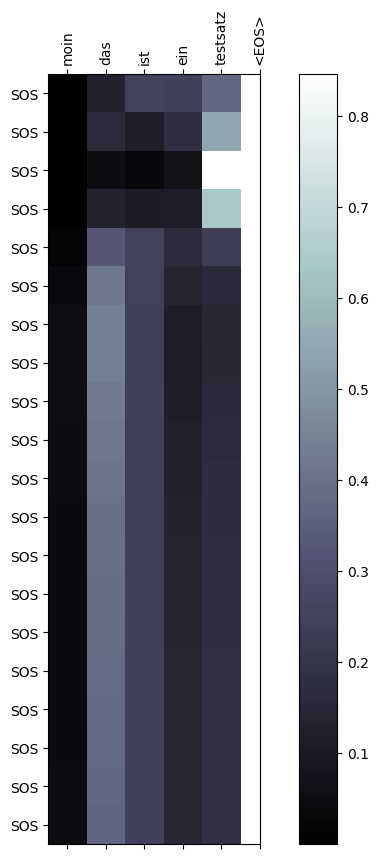

In [ ]:
evaluateAndShowAttention('moin das ist ein testsatz')

In [ ]:
# input_lang, output_lang, dataloader, pairs = get_dataloader(file, batch_size)